## 🌧️ Seattle Rain Prediction

Given *data about weather in Seattle*, let's try to predict how much it will **rain** on a given day.

We will use a variety of regression models to make our predictions.

Data source: https://www.kaggle.com/datasets/rtatman/did-it-rain-in-seattle-19482017

### Importing Libraries

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR, SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score

In [3]:
data = pd.read_csv('archive/seattleWeather_1948-2017.csv')
data

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True
...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False
25547,2017-12-11,0.00,49,29,False
25548,2017-12-12,0.00,46,32,False
25549,2017-12-13,0.00,48,34,False


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  str    
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(1), str(1)
memory usage: 998.2+ KB


### Preprocessing

In [8]:
df = data.copy()

In [9]:
# Missing values
df.isna().sum()

DATE    0
PRCP    3
TMAX    0
TMIN    0
RAIN    3
dtype: int64

In [10]:
# Drop missing rows
df = df.dropna(axis=0).reset_index(drop=True)

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
df

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True
...,...,...,...,...,...
25543,2017-12-10,0.00,49,34,False
25544,2017-12-11,0.00,49,29,False
25545,2017-12-12,0.00,46,32,False
25546,2017-12-13,0.00,48,34,False


In [14]:
# Convert RAIN column to numeric
df['RAIN'] = df['RAIN'].astype(int)

In [17]:
df['DATE'] = pd.to_datetime(df['DATE'])

In [20]:
# Extract Date features
df['YEAR'] = df['DATE'].apply(lambda x: x.year)
df['MONTH'] = df['DATE'].apply(lambda x: x.month)
df['DAY'] = df['DATE'].apply(lambda x: x.day)
df = df.drop('DATE', axis=1)

In [21]:
df

,PRCP,TMAX,TMIN,RAIN,YEAR,MONTH,DAY
0,0.47,51,42,1,1948,1,1
1,0.59,45,36,1,1948,1,2
2,0.42,45,35,1,1948,1,3
3,0.31,45,34,1,1948,1,4
4,0.17,45,32,1,1948,1,5
...,...,...,...,...,...,...,...
25543,0.00,49,34,0,2017,12,10
25544,0.00,49,29,0,2017,12,11
25545,0.00,46,32,0,2017,12,12
25546,0.00,48,34,0,2017,12,13


In [45]:
# Split df into X and y
y = df['PRCP'].copy()
X = df.drop('PRCP', axis=1).copy()

In [46]:
y

0        0.47
1        0.59
2        0.42
3        0.31
4        0.17
         ... 
25543    0.00
25544    0.00
25545    0.00
25546    0.00
25547    0.00
Name: PRCP, Length: 25548, dtype: float64

In [47]:
X

,TMAX,TMIN,RAIN,YEAR,MONTH,DAY
0,51,42,1,1948,1,1
1,45,36,1,1948,1,2
2,45,35,1,1948,1,3
3,45,34,1,1948,1,4
4,45,32,1,1948,1,5
...,...,...,...,...,...,...
25543,49,34,0,2017,12,10
25544,49,29,0,2017,12,11
25545,46,32,0,2017,12,12
25546,48,34,0,2017,12,13


In [48]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

In [49]:
# Scale X
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [50]:
X_train

,TMAX,TMIN,RAIN,YEAR,MONTH,DAY
0,-0.985028,-0.508563,1.150379,-1.220371,1.301661,0.373320
1,2.787580,2.757421,-0.869278,1.657357,0.430591,0.373320
2,0.822680,1.068119,1.150379,-1.021907,0.430591,-0.423973
3,-0.592048,-0.058083,1.150379,0.168877,1.301661,-1.221266
4,-0.592048,0.167157,1.150379,0.069645,-1.601906,1.398411
...,...,...,...,...,...,...
17878,-1.220816,-0.621184,1.150379,-0.277667,1.592018,1.512310
17879,0.193912,0.505018,-0.869278,0.615421,-0.440479,-1.449064
17880,-0.749240,-0.846424,1.150379,-1.021907,-1.021192,0.487219
17881,1.058468,0.842878,-0.869278,-0.079203,-0.730836,1.512310


In [28]:
X_train.describe()

,TMAX,TMIN,RAIN,YEAR,MONTH,DAY
count,1.788300e+04,1.788300e+04,1.788300e+04,1.788300e+04,1.788300e+04,1.788300e+04
mean,9.774284e-17,2.379998e-16,5.800998e-17,1.545608e-15,-6.004628e-17,9.019359e-17
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00
min,-3.421504e+00,-5.013370e+00,-8.692784e-01,-1.716531e+00,-1.601906e+00,-1.676862e+00
25%,-7.492397e-01,-7.338038e-01,-8.692784e-01,-8.730590e-01,-7.308358e-01,-8.795692e-01
50%,-1.204717e-01,5.453730e-02,-8.692784e-01,2.002896e-02,1.402344e-01,3.162269e-02
75%,7.440843e-01,8.428784e-01,1.150379e+00,8.635009e-01,1.011304e+00,8.289156e-01
max,3.416348e+00,2.982661e+00,1.150379e+00,1.706973e+00,1.592018e+00,1.740108e+00


#### Predicting the PRCP column

In [32]:
models = {
    'Linear Regression                       ': LinearRegression(),  
    'Ridge (L2 Regularized Linear Regression)': Ridge(), 
    'K Nearest Neighbors                     ': KNeighborsRegressor(),
    'Decision Trees                          ': DecisionTreeRegressor(),
    'Support Vector Machine (Linear Kernel)  ': LinearSVR(), 
    'Support Vector Machine (RBF Kernel)     ': SVR(),
    'Neural Networks                         ': MLPRegressor(),
    'Random Forests                          ': RandomForestRegressor(), 
    'Gradient Boosting                       ': GradientBoostingRegressor(),
    'XG Boost                                ': XGBRegressor(),
    'Light GBM                               ': LGBMRegressor(),
    'Cat Boost                               ': CatBoostRegressor()
}

In [33]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name + "trained.")

Linear Regression                       trained.
Ridge (L2 Regularized Linear Regression)trained.
K Nearest Neighbors                     trained.
Decision Trees                          trained.


D:\miniconda3\envs\tfenv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Support Vector Machine (Linear Kernel)  trained.
Support Vector Machine (RBF Kernel)     trained.
Neural Networks                         trained.
Random Forests                          trained.
Gradient Boosting                       trained.
XG Boost                                trained.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 265
[LightGBM] [Info] Number of data points in the train set: 17883, number of used features: 6
[LightGBM] [Info] Start training from score 0.105664
Light GBM                               trained.
Learning rate set to 0.064575
0:	learn: 0.2322349	total: 156ms	remaining: 2m 35s
1:	learn: 0.2285481	total: 159ms	remaining: 1m 19s
2:	learn: 0.2249404	total: 163ms	remaining: 54.1s
3:	learn: 0.2218586	total: 166ms	remaining: 41.4s
4:	learn: 0.2190831	total: 170ms	remaining: 33.8s
5:	learn: 0.2164537	total: 174ms	re

### Results

In [34]:
for name, model in models.items():
    print(name + " R^2 : {:.5f}".format(model.score(X_test, y_test)))

Linear Regression                        R^2 : 0.27661
Ridge (L2 Regularized Linear Regression) R^2 : 0.27660
K Nearest Neighbors                      R^2 : 0.22815
Decision Trees                           R^2 : -0.38970
Support Vector Machine (Linear Kernel)   R^2 : 0.17325
Support Vector Machine (RBF Kernel)      R^2 : 0.27201
Neural Networks                          R^2 : 0.32854
Random Forests                           R^2 : 0.23697
Gradient Boosting                        R^2 : 0.33091
XG Boost                                 R^2 : 0.20782
Light GBM                                R^2 : 0.32303
Cat Boost                                R^2 : 0.28960


#### Examining Correlations

In [51]:
corr = pd.concat([X_train, y_train], axis=1).corr()
corr

,TMAX,TMIN,RAIN,YEAR,MONTH,DAY,PRCP
TMAX,1.000000,0.860582,-0.389710,0.062575,0.155203,0.004787,0.008090
TMIN,0.860582,1.000000,-0.138188,0.122744,0.222624,0.004888,0.001804
RAIN,-0.389710,-0.138188,1.000000,-0.016502,-0.043894,-0.006046,-0.008168
YEAR,0.062575,0.122744,-0.016502,1.000000,-0.001206,0.001029,-0.004686
MONTH,0.155203,0.222624,-0.043894,-0.001206,1.000000,0.018366,-0.012046
DAY,0.004787,0.004888,-0.006046,0.001029,0.018366,1.000000,0.009801
PRCP,0.008090,0.001804,-0.008168,-0.004686,-0.012046,0.009801,1.000000


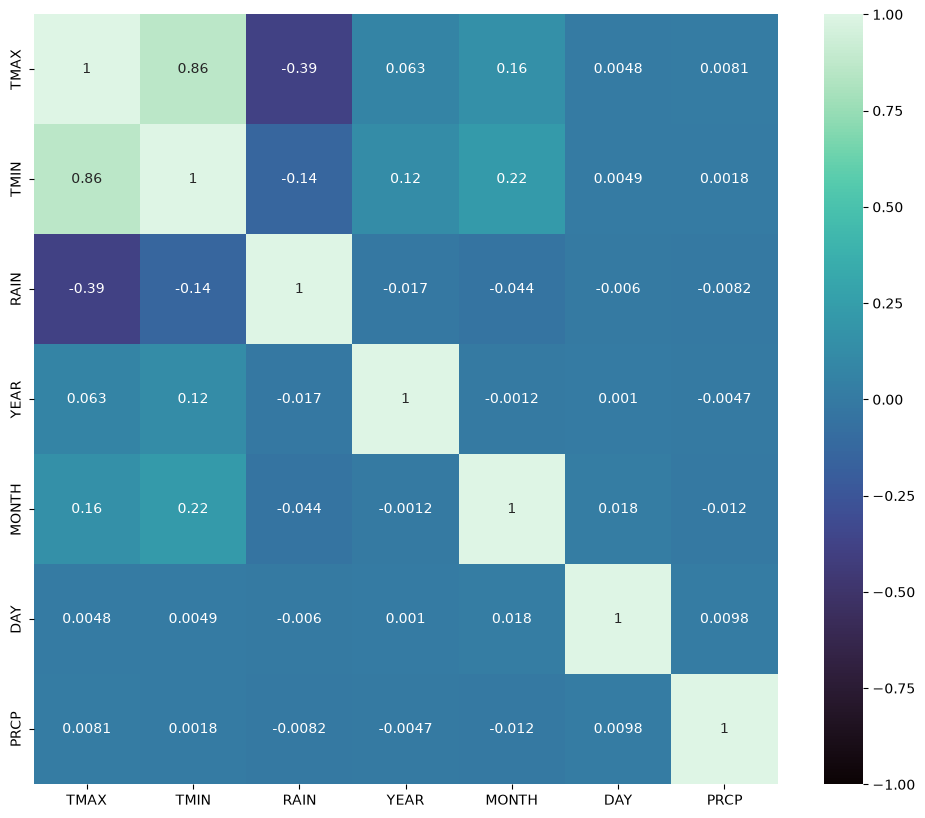

In [52]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, vmin=-1.0, cmap='mako')
plt.show()

#### Predicting the RAIN column

In [73]:
# Split df into X and y
y = df['RAIN'].copy()
X = df.drop('RAIN', axis=1).copy()

# Dropping all columns except PRCP
X = X.drop(['TMAX', 'TMIN', 'YEAR', 'MONTH', 'DAY'], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

# Scale X
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [74]:
X_train

,PRCP
0,-0.361781
1,-0.446246
2,-0.150618
3,1.961010
4,-0.404014
...,...
17878,1.158591
17879,-0.446246
17880,-0.235084
17881,-0.446246


In [75]:
y_train

3975     1
25065    0
5337     1
14188    1
13176    1
        ..
10955    1
17289    0
5192     1
12172    0
235      1
Name: RAIN, Length: 17883, dtype: int64

In [76]:
clf = SVC()
clf.fit(X_train, y_train)

print("Test Accuracy: {:.2f}%".format(clf.score(X_test, y_test) * 100))

Test Accuracy: 100.00%


In [77]:
# Classifying using a simple function

y_pred = X_test > 0
# y_pred = np.squeeze(np.array(y_pred, dtype=int))
y_pred = y_pred.astype(int)
y_pred

,PRCP
0,1
1,0
2,0
3,0
4,0
...,...
7660,0
7661,0
7662,0
7663,1


In [78]:
print("Test Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))

Test Accuracy: 82.87%
